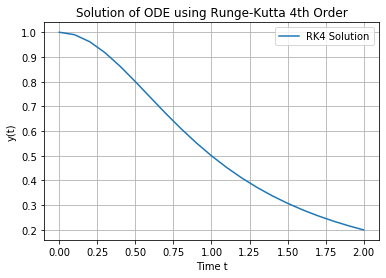

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Define the ODE function, for example, dy/dt = f(t, y) = -2 * t * y^2
def f(t, y):
    return -2 * t * y**2

# Implement the RK4 method
def runge_kutta_4(f, y0, t0, tf, h):
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros(len(t_values))
    
    # Set the initial condition
    y_values[0] = y0
    
    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]
        k1 = h * f(t, y)
        k2 = h * f(t + h / 2, y + k1 / 2)
        k3 = h * f(t + h / 2, y + k2 / 2)
        k4 = h * f(t + h, y + k3)
        
        # Update y based on the RK4 formula
        y_values[i] = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return t_values, y_values

# Set initial conditions and parameters
y0 = 1.0 # Initial value of y
t0 = 0.0 # Initial time
tf = 2.0 # Final time
h = 0.1 # Step size

# Run the RK4 solver
t_values, y_values = runge_kutta_4(f, y0, t0, tf, h)

# Plot the results
plt.plot(t_values, y_values, label='RK4 Solution')
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Solution of ODE using Runge-Kutta 4th Order')
plt.legend()
plt.grid(True)
plt.show()

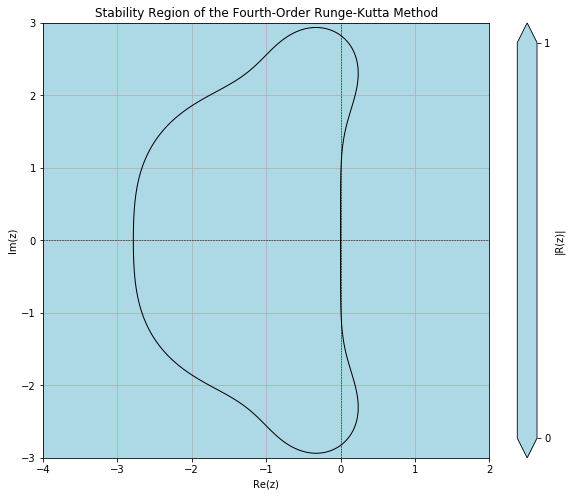

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define the RK4 stability function
def rk4_stability_function(z):
    return 1 + z + (z**2) / 2 + (z**3) / 6 + (z**4) / 24

# Generate a grid of complex numbers (z) in the complex plane

real_vals = np.linspace(-4, 2, 500) # Adjust range for visualization

imag_vals = np.linspace(-3, 3, 500)
real, imag = np.meshgrid(real_vals, imag_vals)

z = real + 1j * imag

# Calculate the magnitude of the stability function
R = rk4_stability_function(z)
magnitude = np.abs(R)

# Plot the stability region where |R(z)| <= 1
plt.figure(figsize=(10, 8))
plt.contourf(real, imag, magnitude, levels=[0, 1],
colors=['lightblue'], extend='both')
plt.colorbar(label='|R(z)|')
plt.contour(real, imag, magnitude, levels=[1], colors='black', linewidths=1)

# Plot aesthetics
plt.title('Stability Region of the Fourth-Order Runge-Kutta Method')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()
